In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize']=(12,6)
plt.rcParams['font.size']=12
sns.set_style("whitegrid")
print("كل المكتبات جاهزة")



كل المكتبات جاهزة


In [2]:
df=pd.read_csv('sample-superstore.csv',encoding='latin1')
print("first 5 rows")
df.head()

first 5 rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#########شكل البيانات

In [3]:
print(f"Dimensions:{df.shape[0]}rows*{df.shape[1]}columns")
print(f"\nCOlumn Names:")
print(df.columns.tolist())

Dimensions:9994rows*21columns

COlumn Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [4]:
###data tyeps
print("dtypes")
print(df.dtypes)

dtypes
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [5]:
####احصاءات الاعمدة الرقمية :
df.describe()      

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
###القبم الناقصة 
missing=df.isnull().sum()
print(missing[missing>0])
if missing.sum()==0:
   print("No missing values found")

Series([], dtype: int64)
No missing values found


In [7]:
###33نظرة علي الفئات والمنتجات :
print(f"Main Categories:{df['Category'].unique()}")
print(f"Regions:{df['Region'].nunique()}")
print(f"Unique Products:{df['Product Name'].nunique()}")
print(f"Unique Customers:{df['Customer Name'].nunique()}")
print(f"Date Range:{df['Order Date'].min()}to{df['Order Date'].max()}")


Main Categories:['Furniture' 'Office Supplies' 'Technology']
Regions:4
Unique Products:1850
Unique Customers:793
Date Range:1/1/2017to9/9/2017


In [8]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


# my note from the first day :
#### data size =
9994 rows* 21columns

Main Categories:['Furniture' 'Office Supplies' 'Technology']
Regions:4



In [9]:
print("dtypes")
print(df.dtypes)


dtypes
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [10]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])
df['Postal Code']=df['Postal Code'].astype(str)
print(df[['Order Date','Ship Date','Postal Code']].dtypes)


Order Date     datetime64[ns]
Ship Date      datetime64[ns]
Postal Code            object
dtype: object


In [11]:
df['Order Year']=df['Order Date'].dt.year
df['Order Month']=df['Order Date'].dt.month
df['Order Day']=df['Order Date'].dt.day_name()
df['Shipping Days']=(df['Ship Date']-df['Order Date']).dt.days
print(df[['Order Date','Order Year','Order Month','Order Day','Shipping Days']].head())

  Order Date  Order Year  Order Month Order Day  Shipping Days
0 2016-11-08        2016           11   Tuesday              3
1 2016-11-08        2016           11   Tuesday              3
2 2016-06-12        2016            6    Sunday              4
3 2015-10-11        2015           10    Sunday              7
4 2015-10-11        2015           10    Sunday              7


In [12]:
print(f"Total Sales:${df['Sales'].sum():,.2f}")
print(f"Total Profit:${df['Profit'].sum():,.2f}")
print(f"Profit Margin:{df['Profit'].sum()/df['Sales'].sum()*100:.1f}%")
print(f"Totale Order:{df['Order ID'].nunique()}")
print(f"Total Products:{df['Product Name'].nunique()}")
print(f"Total Customers:{df['Customer Name'].nunique()}")
    

Total Sales:$2,297,200.86
Total Profit:$286,397.02
Profit Margin:12.5%
Totale Order:5009
Total Products:1850
Total Customers:793


In [13]:
category_analysis=df.groupby('Category').agg(Total_Sales=('Sales','sum'),
Total_Profit=('Profit','sum'),
Total_orders=('Order ID','count')).round(2)
category_analysis['Profit_Margin']=(category_analysis['Total_Profit']/
category_analysis['Total_Sales']*100).round(1) 
print(category_analysis.sort_values('Total_Sales',ascending=False))
                                              


                 Total_Sales  Total_Profit  Total_orders  Profit_Margin
Category                                                               
Technology         836154.03     145454.95          1847           17.4
Furniture          741999.80      18451.27          2121            2.5
Office Supplies    719047.03     122490.80          6026           17.0


In [14]:
regoin_analysis=df.groupby('Region').agg(Total_Sales=('Sales','sum'),
Total_Profit=('Profit','sum'),
Total_orders=('Order ID','count')).round(2)
regoin_analysis['Profit_Margin']=(regoin_analysis['Total_Profit']/
regoin_analysis['Total_Sales']*100).round(1) 
print(regoin_analysis.sort_values('Total_Profit',ascending=False))

         Total_Sales  Total_Profit  Total_orders  Profit_Margin
Region                                                         
West       725457.82     108418.45          3203           14.9
East       678781.24      91522.78          2848           13.5
South      391721.90      46749.43          1620           11.9
Central    501239.89      39706.36          2323            7.9


In [15]:
losing_products=df[df['Profit']<0].groupby('Product Name').agg(Total_loss=('Profit','sum'),
total_Orders=('Order ID','count')).round(2) 
losing_products=losing_products.sort_values('Total_loss')
print(f"Number of losing products:{len(losing_products)}")
print(losing_products.head(10))

Number of losing products:766
                                                    Total_loss  total_Orders
Product Name                                                                
Cubify CubeX 3D Printer Double Head Print             -9239.97             2
GBC DocuBind P400 Electric Binding System             -6859.39             3
Lexmark MX611dhe Monochrome Laser Printer             -5269.97             3
GBC Ibimaster 500 Manual ProClick Binding System      -5098.57             6
GBC DocuBind TL300 Electric Binding System            -4162.03             4
Cubify CubeX 3D Printer Triple Head Print             -3839.99             1
Fellowes PB500 Electric Punch Plastic Comb Bind...    -3431.67             2
Chromcraft Bull-Nose Wood Oval Conference Table...    -3107.53             4
Ibico EPK-21 Electric Binding System                  -2929.48             1
Bush Advantage Collection Racetrack Conference ...    -2545.26             6


##day 3finishing:
###  category analysis
- technolgy:highest sales+17.4% margin= star product
- furniture:high sales but only 2.5% margin = need review
- office supplies: most order(6026)with solid 17% margin
 ### regional analysis
 west: best region in sales and profit
 center:sells mor than south but profit less (7.9%)
  ### loss-making products
  766 out of 1850 products are unprofitable (41%)
  -biggest loss:cubifty 3D printer ($9.239 in 2 orders only)





In [16]:
segment_analysis=df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_profit=('Profit', 'sum'),
    Total_Order=('Order ID', 'count'),
    Avg_Order=('Sales', 'mean'),
).round(2)
segment_analysis['Profit_Margin']=(
    segment_analysis['Total_profit']/
    segment_analysis['Total_Sales']*100
).round(1)
print(segment_analysis.sort_values('Total_profit',ascending=False))



             Total_Sales  Total_profit  Total_Order  Avg_Order  Profit_Margin
Segment                                                                      
Consumer      1161401.34     134119.21         5191     223.73           11.5
Corporate      706146.37      91979.13         3020     233.82           13.0
Home Office    429653.15      60298.68         1783     240.97           14.0


In [17]:
discount_analysis=df.groupby('Discount').agg(
    Avg_Profit=('Profit','mean'),
    Avg_Sales=('Sales','mean'),
    Count=('Order ID','count')).round(2)
print(discount_analysis.sort_values('Discount'))

          Avg_Profit  Avg_Sales  Count
Discount                              
0.00           66.90     226.74   4798
0.10           96.06     578.40     94
0.15           27.29     529.97     52
0.20           24.70     209.08   3657
0.30          -45.68     454.74    227
0.32          -88.56     536.79     27
0.40         -111.93     565.13    206
0.45         -226.65     498.63     11
0.50         -310.70     892.71     66
0.60          -43.08      48.15    138
0.70          -95.87      97.18    418
0.80         -101.80      56.55    300


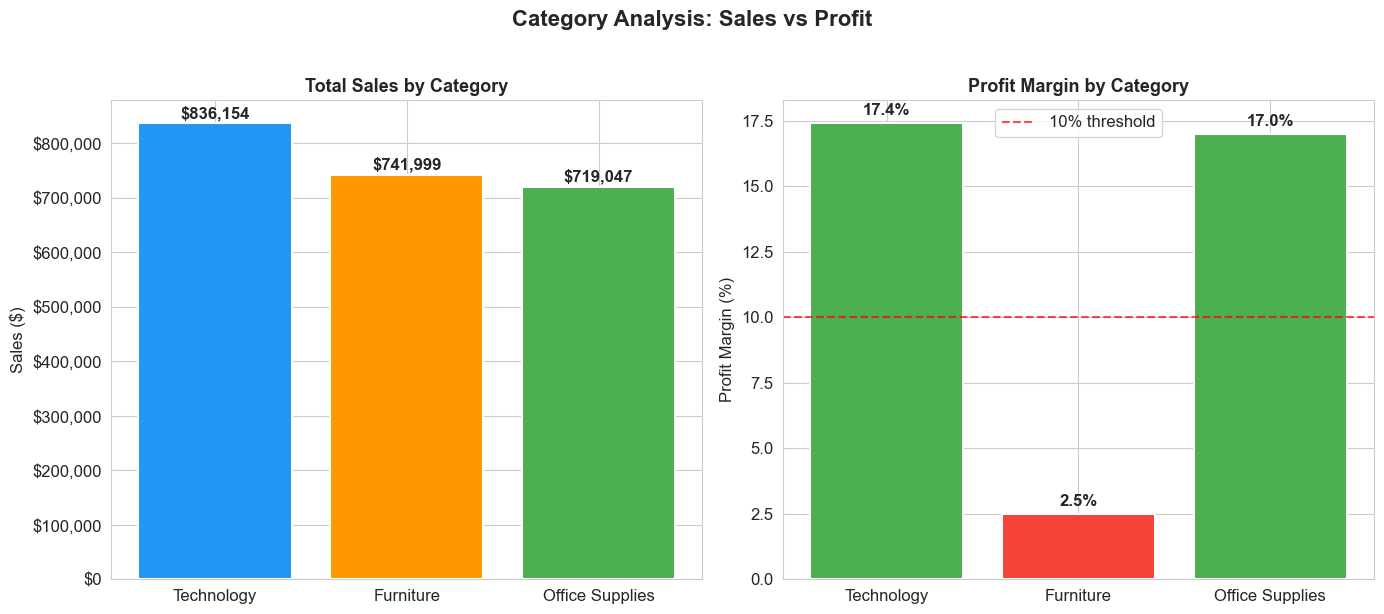

Chart saved!


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Category Analysis: Sales vs Profit',
fontsize=16, fontweight='bold', y=1.02)

# Chart 1: Sales by Category
categories = ['Technology', 'Furniture', 'Office Supplies']
sales = [836154, 741999, 719047]
colors_sales = ['#2196F3', '#FF9800', '#4CAF50']
axes[0].bar(categories, sales, color=colors_sales, edgecolor='white', linewidth=1.5)
axes[0].set_title('Total Sales by Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
for i, v in enumerate(sales):
    axes[0].text(i, v + 10000, f'${v:,.0f}', ha='center', fontweight='bold')

# Chart 2: Profit Margin by Category
margins = [17.4, 2.5, 17.0]
colors_margin = ['#4CAF50' if m > 10 else '#F44336' for m in margins]
axes[1].bar(categories, margins, color=colors_margin, edgecolor='white', linewidth=1.5)
axes[1].set_title('Profit Margin by Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].axhline(y=10, color='red', linestyle='--', alpha=0.7, label='10% threshold')
axes[1].legend()
for i, v in enumerate(margins):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

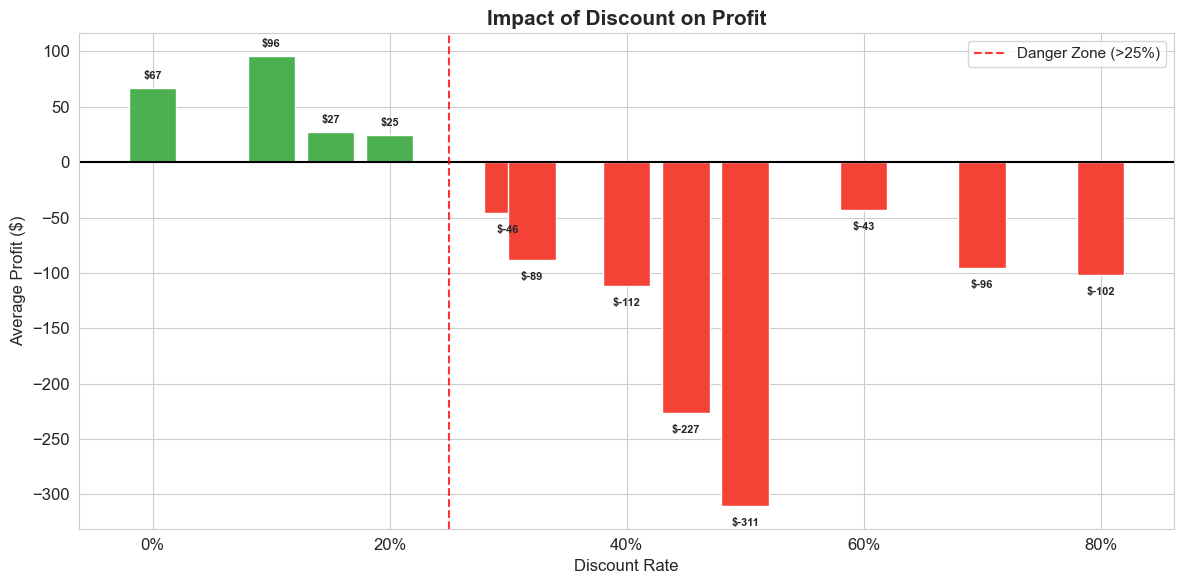

Chart saved!


In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

discounts = [0.0, 0.1, 0.15, 0.2, 0.3, 0.32, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8]
profits = [66.90, 96.06, 27.29, 24.70, -45.68, -88.56,
-111.93, -226.65, -310.70, -43.08, -95.87, -101.80]

colors = ['#4CAF50' if p > 0 else '#F44336' for p in profits]

ax.bar(discounts, profits, color=colors, width=0.04, edgecolor='white')
ax.axhline(y=0, color='black', linewidth=1.5)
ax.axvline(x=0.25, color='red', linestyle='--',
alpha=0.8, label='Danger Zone (>25%)')

ax.set_title('Impact of Discount on Profit',
fontsize=15, fontweight='bold')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Average Profit ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
ax.legend(fontsize=11)

for i, (d, p) in enumerate(zip(discounts, profits)):
    ax.text(d, p + (8 if p > 0 else -18),
    f'${p:.0f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('discount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

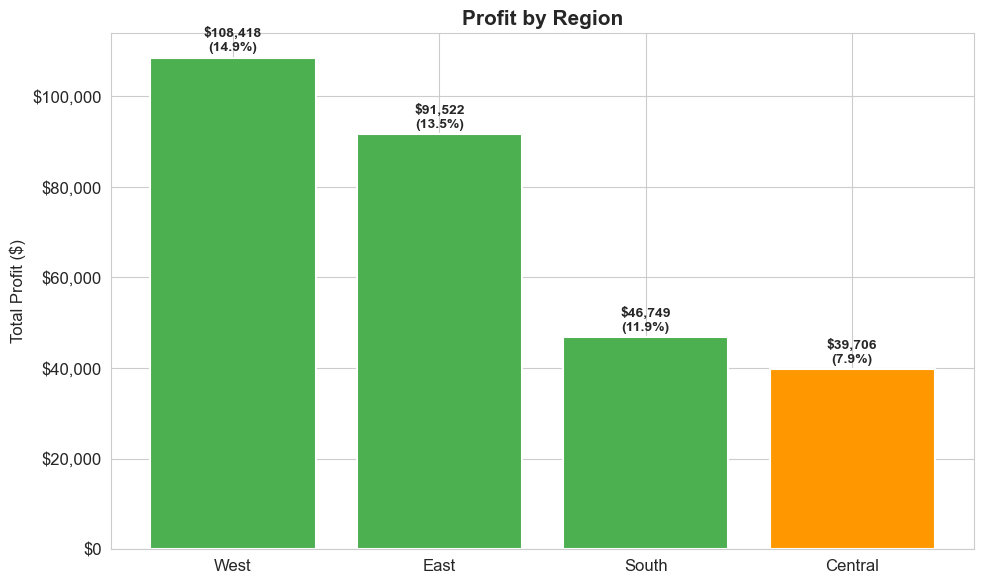

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

regions = ['West', 'East', 'South', 'Central']
profits = [108418, 91522, 46749, 39706]
margins = [14.9, 13.5, 11.9, 7.9]
colors = ['#4CAF50' if m > 10 else '#FF9800' for m in margins]

bars = ax.bar(regions, profits, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Profit by Region', fontsize=15, fontweight='bold')
ax.set_ylabel('Total Profit ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

for i, (p, m) in enumerate(zip(profits, margins)):
    ax.text(i, p + 1500, f'${p:,.0f}\n({m}%)',
    ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('region_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


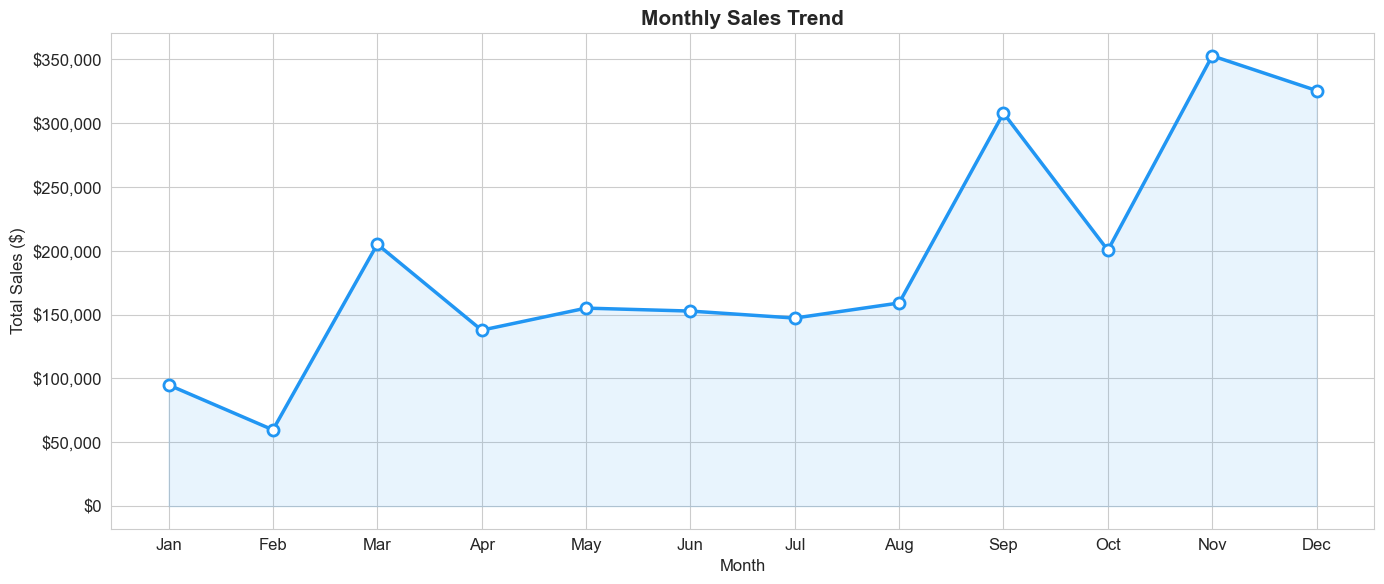

In [28]:
fig, ax = plt.subplots(figsize=(14, 6))

monthly_sales = df.groupby('Order Month')['Sales'].sum().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
'Jul','Aug','Sep','Oct','Nov','Dec']

ax.plot(monthly_sales['Order Month'], monthly_sales['Sales'],
color='#2196F3', linewidth=2.5, marker='o',
markersize=8, markerfacecolor='white', markeredgewidth=2)

ax.fill_between(monthly_sales['Order Month'],
monthly_sales['Sales'], alpha=0.1, color='#2196F3')

ax.set_title('Monthly Sales Trend', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()


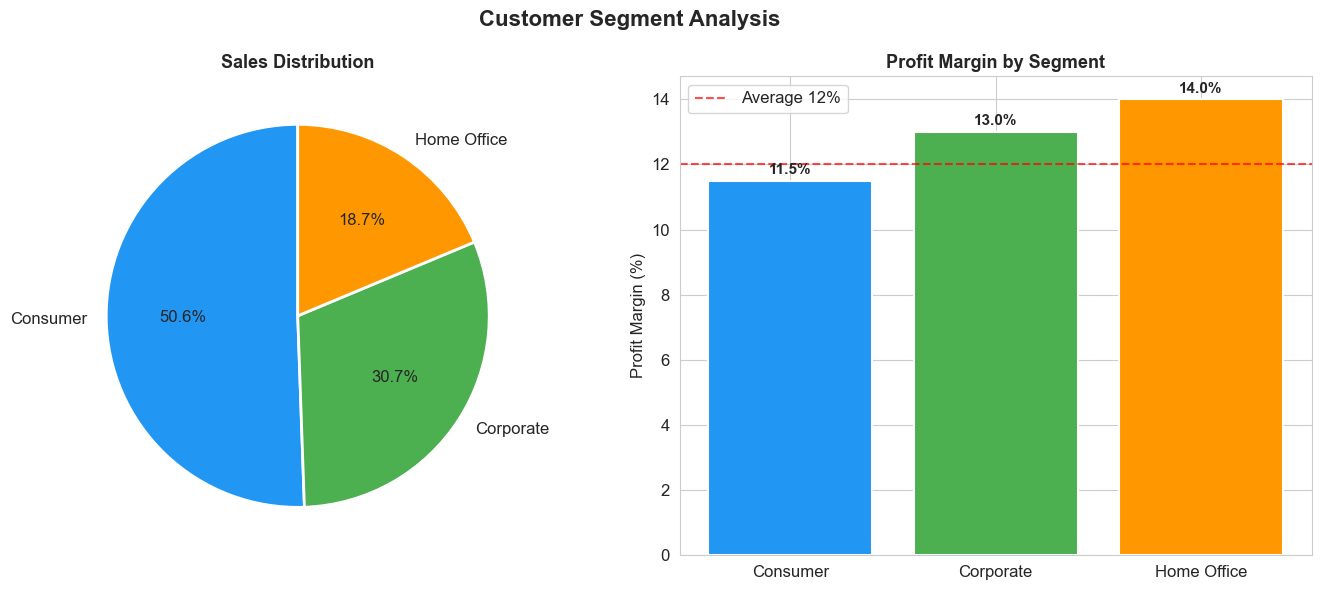

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Customer Segment Analysis', fontsize=16, fontweight='bold')

segments = ['Consumer', 'Corporate', 'Home Office']
sales = [1161401, 706146, 429653]
margins = [11.5, 13.0, 14.0]
colors = ['#2196F3', '#4CAF50', '#FF9800']

# Pie Chart
axes[0].pie(sales, labels=segments, colors=colors,
autopct='%1.1f%%', startangle=90,
wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Sales Distribution', fontsize=13, fontweight='bold')

# Margin Bar Chart
bars = axes[1].bar(segments, margins, color=colors,
edgecolor='white', linewidth=1.5)
axes[1].set_title('Profit Margin by Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].axhline(y=12, color='red', linestyle='--',
alpha=0.7, label='Average 12%')
axes[1].legend()

for i, m in enumerate(margins):
    axes[1].text(i, m + 0.2, f'{m}%',
ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



In [31]:
print("=" * 55)
print("SUPERSTORE ANALYSIS - KEY FINDINGS")
print("=" * 55)

print("\n📊 OVERVIEW")
print(f" Total Sales: $2,297,200")
print(f" Total Profit: $286,397")
print(f" Profit Margin: 12.5%")
print(f" Total Customers: 793")

print("\n🔴 PROBLEMS FOUND")
print(" 1. Furniture margin only 2.5% (danger zone)")
print(" 2. 766 products sold at a loss (41% of catalog)")
print(" 3. Discounts above 30% always cause losses")
print(" 4. Central region: high sales but low profit 7.9%")

print("\n🟢 OPPORTUNITIES FOUND")
print(" 1. Technology: best margin 17.4%")
print(" 2. Home Office: highest margin 14% per segment")
print(" 3. November: peak sales month")
print(" 4. No discount = highest average profit $66")

print("\n💡 RECOMMENDATIONS")
print(" 1. Cap discounts at 20% maximum")
print(" 2. Review Furniture pricing strategy")
print(" 3. Investigate Central region high costs")
print(" 4. Focus marketing on Home Office segment")
print(" 5. Boost inventory before November peak")
print("=" * 55)

SUPERSTORE ANALYSIS - KEY FINDINGS

📊 OVERVIEW
 Total Sales: $2,297,200
 Total Profit: $286,397
 Profit Margin: 12.5%
 Total Customers: 793

🔴 PROBLEMS FOUND
 1. Furniture margin only 2.5% (danger zone)
 2. 766 products sold at a loss (41% of catalog)
 3. Discounts above 30% always cause losses
 4. Central region: high sales but low profit 7.9%

🟢 OPPORTUNITIES FOUND
 1. Technology: best margin 17.4%
 2. Home Office: highest margin 14% per segment
 3. November: peak sales month
 4. No discount = highest average profit $66

💡 RECOMMENDATIONS
 1. Cap discounts at 20% maximum
 2. Review Furniture pricing strategy
 3. Investigate Central region high costs
 4. Focus marketing on Home Office segment
 5. Boost inventory before November peak


In [32]:
customer_value = df.groupby('Customer Name').agg(
Total_Sales = ('Sales', 'sum'),
Total_Profit = ('Profit', 'sum'),
Total_Orders = ('Order ID', 'nunique')
).round(2)

customer_value['Avg_Order_Value'] = (
customer_value['Total_Sales'] /
customer_value['Total_Orders']
).round(2)

print("TOP 10 MOST VALUABLE CUSTOMERS:")
print(customer_value.sort_values('Total_Profit', ascending=False).head(10))

print("\nBOTTOM 10 LEAST PROFITABLE CUSTOMERS:")
print(customer_value.sort_values('Total_Profit').head(10))


TOP 10 MOST VALUABLE CUSTOMERS:
                      Total_Sales  Total_Profit  Total_Orders  Avg_Order_Value
Customer Name                                                                 
Tamara Chand             19052.22       8981.32             5          3810.44
Raymond Buch             15117.34       6976.10             6          2519.56
Sanjit Chand             14142.33       5757.41             9          1571.37
Hunter Lopez             12873.30       5622.43             6          2145.55
Adrian Barton            14473.57       5444.81            10          1447.36
Tom Ashbrook             14595.62       4703.79             4          3648.90
Christopher Martinez      8954.02       3899.89             4          2238.50
Keith Dawkins             8181.26       3038.63            12           681.77
Andy Reiter               6608.45       2884.62             6          1101.41
Daniel Raglin             8350.87       2869.08             8          1043.86

BOTTOM 10 LEAST PRO

In [33]:
product_profit = df.groupby('Product Name').agg(
Total_Profit = ('Profit', 'sum'),
Total_Sales = ('Sales', 'sum'),
Total_Orders = ('Order ID', 'count')
).round(2)

print("TOP 10 MOST PROFITABLE PRODUCTS:")
print(product_profit.sort_values(
'Total_Profit', ascending=False
).head(10))

print("\nTOP 10 LOSS-MAKING PRODUCTS:")
print(product_profit.sort_values('Total_Profit').head(10))

TOP 10 MOST PROFITABLE PRODUCTS:
                                                    Total_Profit  Total_Sales  \
Product Name                                                                    
Canon imageCLASS 2200 Advanced Copier                   25199.93     61599.82   
Fellowes PB500 Electric Punch Plastic Comb Bind...       7753.04     27453.38   
Hewlett Packard LaserJet 3310 Copier                     6983.88     18839.69   
Canon PC1060 Personal Laser Copier                       4570.93     11619.83   
HP Designjet T520 Inkjet Large Format Printer -...       4094.98     18374.90   
Ativa V4110MDD Micro-Cut Shredder                        3772.95      7699.89   
3D Systems Cube Printer, 2nd Generation, Magenta         3717.97     14299.89   
Plantronics Savi W720 Multi-Device Wireless Hea...       3696.28      9367.29   
Ibico EPK-21 Electric Binding System                     3345.28     15875.92   
Zebra ZM400 Thermal Label Printer                        3343.54      6965.7

In [34]:
monthly = df.groupby(['Order Year', 'Order Month']).agg(
Total_Sales = ('Sales', 'sum'),
Total_Profit = ('Profit', 'sum')
).round(2)

monthly['Profit_Margin'] = (
monthly['Total_Profit'] /
monthly['Total_Sales'] * 100
).round(1)

print("MONTHLY PERFORMANCE BY YEAR:")
print(monthly)

best_month = df.groupby('Order Month')['Sales'].sum()
print(f"\nBEST MONTH: {best_month.idxmax()}")
print(f"WORST MONTH: {best_month.idxmin()}")
print(f"\nBest month sales: ${best_month.max():,.0f}")
print(f"Worst month sales: ${best_month.min():,.0f}")

MONTHLY PERFORMANCE BY YEAR:
                        Total_Sales  Total_Profit  Profit_Margin
Order Year Order Month                                          
2014       1               14236.90       2450.19           17.2
           2                4519.89        862.31           19.1
           3               55691.01        498.73            0.9
           4               28295.34       3488.84           12.3
           5               23648.29       2738.71           11.6
           6               34595.13       4976.52           14.4
           7               33946.39       -841.48           -2.5
           8               27909.47       5318.10           19.1
           9               81777.35       8328.10           10.2
           10              31453.39       3448.26           11.0
           11              78628.72       9292.13           11.8
           12              69545.62       8983.57           12.9
2015       1               18174.08      -3281.01          -1

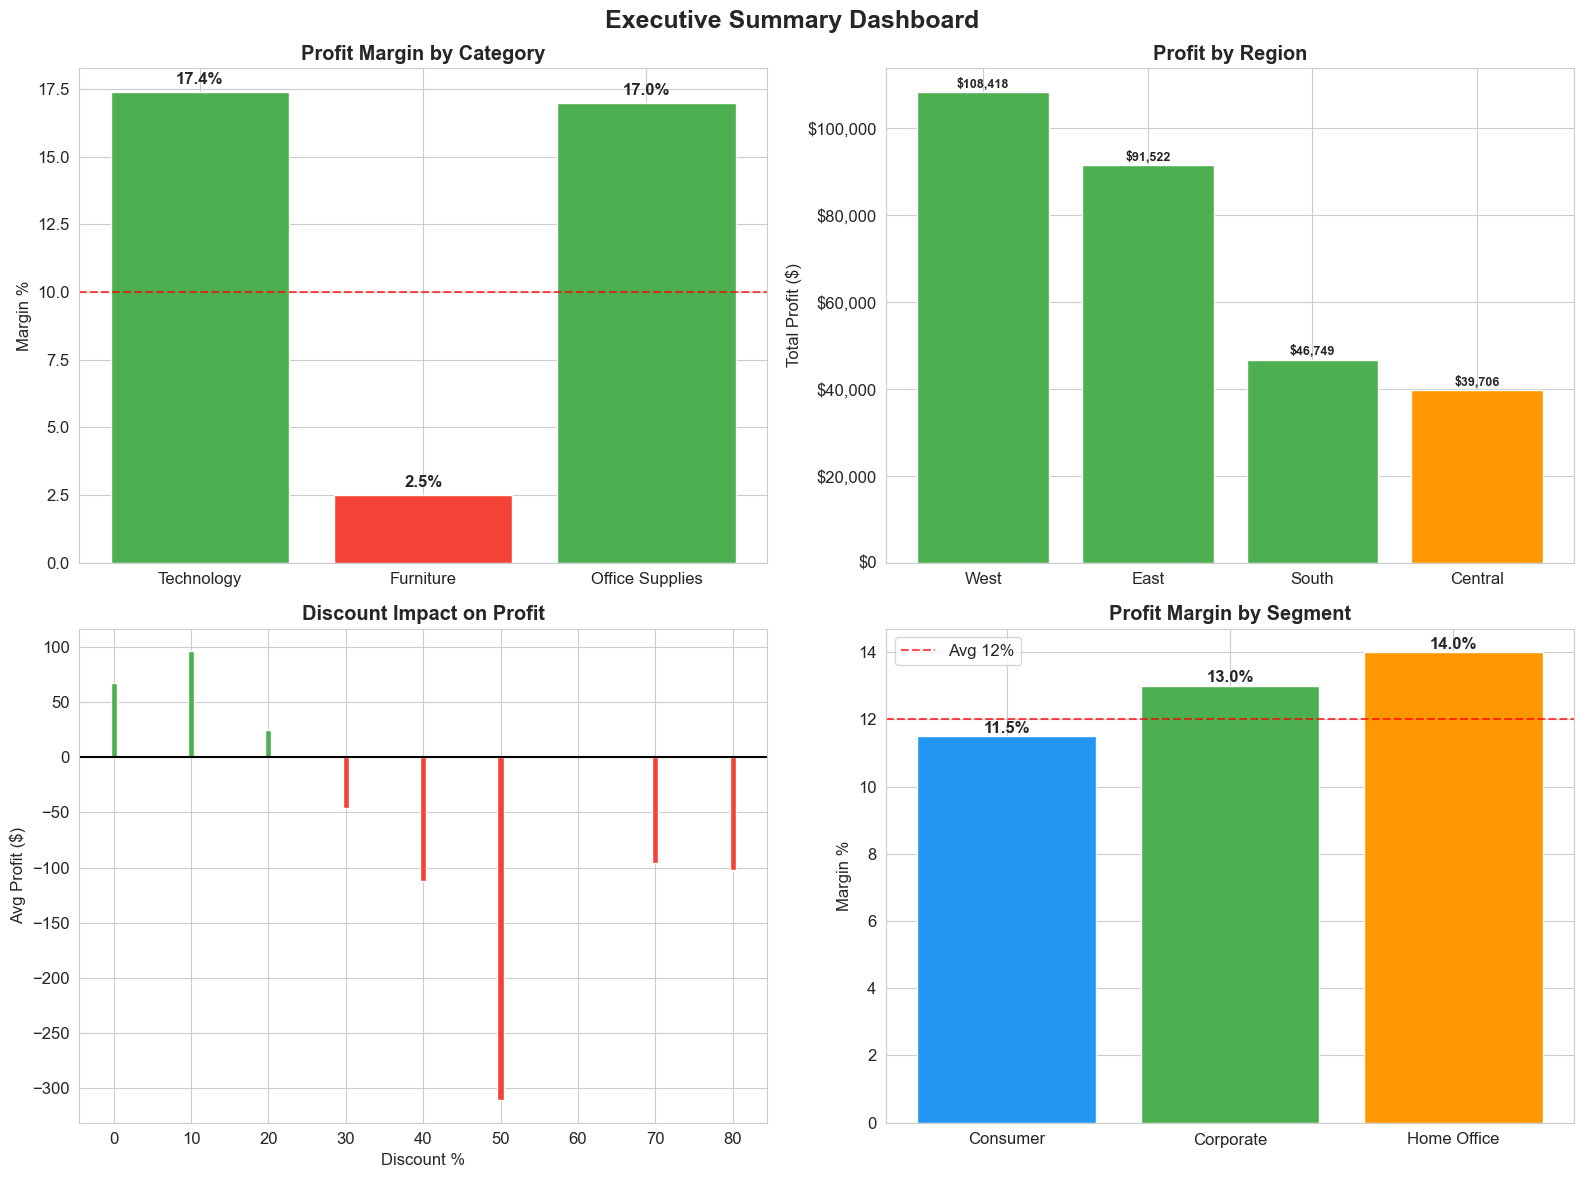

Dashboard saved!


In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Executive Summary Dashboard',
fontsize=18, fontweight='bold')

# Chart 1: Category Profit Margin
categories = ['Technology', 'Furniture', 'Office Supplies']
margins = [17.4, 2.5, 17.0]
colors1 = ['#4CAF50' if m > 10 else '#F44336' for m in margins]

axes[0,0].bar(categories, margins, color=colors1, edgecolor='white')
axes[0,0].axhline(y=10, color='red', linestyle='--', alpha=0.7)
axes[0,0].set_title('Profit Margin by Category', fontweight='bold')
axes[0,0].set_ylabel('Margin %')
for i, m in enumerate(margins):
    axes[0,0].text(i, m+0.3, f'{m}%', ha='center', fontweight='bold')

# Chart 2: Region Performance
regions = ['West', 'East', 'South', 'Central']
profits = [108418, 91522, 46749, 39706]
colors2 = ['#4CAF50','#4CAF50','#4CAF50','#FF9800']

axes[0,1].bar(regions, profits, color=colors2, edgecolor='white')
axes[0,1].set_title('Profit by Region', fontweight='bold')
axes[0,1].set_ylabel('Total Profit ($)')
axes[0,1].yaxis.set_major_formatter(
plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
for i, p in enumerate(profits):
    axes[0,1].text(i, p+1000, f'${p:,.0f}',
    ha='center', fontsize=9, fontweight='bold')

# Chart 3: Discount Impact
discounts = [0, 10, 20, 30, 40, 50, 70, 80]
avg_profit= [66.90, 96.06, 24.70, -45.68, -111.93, -310.70, -95.87, -101.80]
colors3 = ['#4CAF50' if p > 0 else '#F44336' for p in avg_profit]

axes[1,0].bar(discounts, avg_profit, color=colors3, edgecolor='white')
axes[1,0].axhline(y=0, color='black', linewidth=1.5)
axes[1,0].set_title('Discount Impact on Profit', fontweight='bold')
axes[1,0].set_xlabel('Discount %')
axes[1,0].set_ylabel('Avg Profit ($)')

# Chart 4: Segment Margins
segments = ['Consumer', 'Corporate', 'Home Office']
seg_margins = [11.5, 13.0, 14.0]
colors4 = ['#2196F3', '#4CAF50', '#FF9800']

axes[1,1].bar(segments, seg_margins, color=colors4, edgecolor='white')
axes[1,1].axhline(y=12, color='red', linestyle='--',
alpha=0.7, label='Avg 12%')
axes[1,1].set_title('Profit Margin by Segment', fontweight='bold')
axes[1,1].set_ylabel('Margin %')
axes[1,1].legend()
for i, m in enumerate(seg_margins):
    axes[1,1].text(i, m+0.1, f'{m}%',
    ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")



# Superstore Sales Analysis
## Business Intelligence Case Study

**Analyst:** Hanaa Ahmed
**Date:** March 2026
**Tools:** Python | Pandas | Matplotlib | Seaborn
**Dataset:** Superstore Sales — 9,994 records | 2015-2018

---

## Business Problem
A retail company needs to understand:
- Which products and categories are most profitable?
- Which regions need attention?
- Are discounts helping or hurting profit?
- Who are the most valuable customers?

---

## Key Findings
| Area | Finding | Impact |
|------|---------|--------|
| Furniture | 2.5% margin only | 🔴 Critical |
| Discounts >30% | Always cause losses | 🔴 Critical |
| Technology | 17.4% margin | 🟢 Opportunity |
| Home Office | Highest margin 14% | 🟢 Opportunity |
| November | Peak sales month | 🟢 Opportunity |
| Central Region | 7.9% margin only | 🟡 Warning |

---

## Recommendations
1. Cap all discounts at 20% maximum
2. Review Furniture pricing strategy
3. Focus marketing on Home Office segment
4. Boost Technology inventory
5. Prepare stock before November peak
6. Investigate Central region costs

In [66]:
pip install reportlab --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [67]:
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.platypus import (SimpleDocTemplate, Paragraph,
Spacer, Table, TableStyle,
HRFlowable)

doc = SimpleDocTemplate(
"Superstore_Analysis_Report.pdf",
pagesize=letter,
rightMargin=0.75*inch, leftMargin=0.75*inch,
topMargin=0.75*inch, bottomMargin=0.75*inch
)

styles = getSampleStyleSheet()

# Custom styles
title_style = ParagraphStyle(
'CustomTitle',
parent=styles['Title'],
fontSize=24, textColor=colors.HexColor('#0A2342'),
spaceAfter=6
)
heading_style = ParagraphStyle(
'CustomHeading',
parent=styles['Heading2'],
fontSize=13, textColor=colors.HexColor('#0A2342'),
spaceBefore=14, spaceAfter=6
)
body_style = ParagraphStyle(
'CustomBody',
parent=styles['Normal'],
fontSize=10, leading=16
)

story = []

# ── Title Page ──
story.append(Paragraph("Superstore Sales Analysis", title_style))
story.append(Paragraph("Business Intelligence Case Study", styles['Heading2']))
story.append(HRFlowable(width="100%", thickness=2,
color=colors.HexColor('#C9A84C')))
story.append(Spacer(1, 0.2*inch))

info_data = [
['Analyst', 'Hanaa'],
['Date', 'March 2026'],
['Tools', 'Python | Pandas | Matplotlib | Seaborn'],
['Dataset', '9,994 records | 2015-2018'],
['Industry', 'Retail / E-commerce'],
]
info_table = Table(info_data, colWidths=[1.5*inch, 5*inch])
info_table.setStyle(TableStyle([
('FONTNAME', (0,0), (-1,-1), 'Helvetica'),
('FONTSIZE', (0,0), (-1,-1), 10),
('FONTNAME', (0,0), (0,-1), 'Helvetica-Bold'),
('TEXTCOLOR', (0,0), (0,-1), colors.HexColor('#0A2342')),
('ROWBACKGROUNDS',(0,0),(-1,-1),
[colors.HexColor('#F5F7FA'), colors.white]),
('PADDING', (0,0), (-1,-1), 8),
]))
story.append(info_table)
story.append(Spacer(1, 0.3*inch))

# ── Overview ──
story.append(Paragraph("📊 Business Overview", heading_style))
story.append(HRFlowable(width="100%", thickness=1,
color=colors.HexColor('#E2E8F0')))
story.append(Spacer(1, 0.1*inch))

overview_data = [
['Metric', 'Value'],
['Total Sales', '$2,297,200'],
['Total Profit', '$286,397'],
['Profit Margin', '12.5%'],
['Total Orders', '5,009'],
['Total Products', '1,850'],
['Total Customers', '793'],
]
ov_table = Table(overview_data, colWidths=[3*inch, 3*inch])
ov_table.setStyle(TableStyle([
('BACKGROUND', (0,0), (-1,0), colors.HexColor('#0A2342')),
('TEXTCOLOR', (0,0), (-1,0), colors.white),
('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
('FONTNAME', (0,1), (-1,-1), 'Helvetica'),
('FONTSIZE', (0,0), (-1,-1), 10),
('ROWBACKGROUNDS',(0,1),(-1,-1),
[colors.HexColor('#F5F7FA'), colors.white]),
('ALIGN', (1,0), (1,-1), 'CENTER'),
('PADDING', (0,0), (-1,-1), 8),
('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#E2E8F0')),
]))
story.append(ov_table)
story.append(Spacer(1, 0.3*inch))

# ── Problems ──
story.append(Paragraph("🔴 Problems Found", heading_style))
story.append(HRFlowable(width="100%", thickness=1,
color=colors.HexColor('#E2E8F0')))
story.append(Spacer(1, 0.1*inch))

problems = [
['#', 'Problem', 'Severity'],
['1', 'Furniture margin only 2.5%', '🔴 Critical'],
['2', '766 products sold at a loss (41%)', '🔴 Critical'],
['3', 'Discounts above 30% cause losses', '🔴 Critical'],
['4', 'Central region: low margin 7.9%', '🟡 Warning'],
]
pr_table = Table(problems, colWidths=[0.4*inch, 4*inch, 1.5*inch])
pr_table.setStyle(TableStyle([
('BACKGROUND', (0,0), (-1,0), colors.HexColor('#B91C1C')),
('TEXTCOLOR', (0,0), (-1,0), colors.white),
('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
('FONTNAME', (0,1), (-1,-1), 'Helvetica'),
('FONTSIZE', (0,0), (-1,-1), 10),
('ROWBACKGROUNDS',(0,1),(-1,-1),
[colors.HexColor('#FEF2F2'), colors.white]),
('PADDING', (0,0), (-1,-1), 8),
('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#E2E8F0')),
]))
story.append(pr_table)
story.append(Spacer(1, 0.3*inch))

# ── Opportunities ──
story.append(Paragraph("🟢 Opportunities Found", heading_style))
story.append(HRFlowable(width="100%", thickness=1,
color=colors.HexColor('#E2E8F0')))
story.append(Spacer(1, 0.1*inch))

opps = [
['#', 'Opportunity', 'Potential'],
['1', 'Technology: best margin 17.4%', '🟢 High'],
['2', 'Home Office: highest margin 14%', '🟢 High'],
['3', 'November: peak sales month', '🟢 High'],
['4', 'Top customer Tamara Chand: $8,981', '🟢 Medium'],
]
op_table = Table(opps, colWidths=[0.4*inch, 4*inch, 1.5*inch])
op_table.setStyle(TableStyle([
('BACKGROUND', (0,0), (-1,0), colors.HexColor('#15803D')),
('TEXTCOLOR', (0,0), (-1,0), colors.white),
('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
('FONTNAME', (0,1), (-1,-1), 'Helvetica'),
('FONTSIZE', (0,0), (-1,-1), 10),
('ROWBACKGROUNDS',(0,1),(-1,-1),
[colors.HexColor('#DCFCE7'), colors.white]),
('PADDING', (0,0), (-1,-1), 8),
('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#E2E8F0')),
]))
story.append(op_table)
story.append(Spacer(1, 0.3*inch))

# ── Recommendations ──
story.append(Paragraph("💡 Recommendations", heading_style))
story.append(HRFlowable(width="100%", thickness=1,
color=colors.HexColor('#E2E8F0')))
story.append(Spacer(1, 0.1*inch))

recs = [
['Priority', 'Recommendation', 'Expected Impact'],
['High', 'Cap discounts at 20% maximum', 'Reduce losses immediately'],
['High', 'Review Furniture pricing', 'Improve 2.5% margin'],
['High', 'Focus on Home Office marketing', 'Higher profit per order'],
['Medium', 'Investigate Central region costs', 'Improve 7.9% margin'],
['Medium', 'Boost stock before November', 'Maximize peak season'],
['Low', 'Retain top customers with offers', 'Increase repeat orders'],
]
rc_table = Table(recs, colWidths=[0.9*inch, 3.1*inch, 1.9*inch])
rc_table.setStyle(TableStyle([
('BACKGROUND', (0,0), (-1,0), colors.HexColor('#0A2342')),
('TEXTCOLOR', (0,0), (-1,0), colors.white),
('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
('FONTNAME', (0,1), (-1,-1), 'Helvetica'),
('FONTSIZE', (0,0), (-1,-1), 10),
('ROWBACKGROUNDS',(0,1),(-1,-1),
[colors.HexColor('#F5F7FA'), colors.white]),
('PADDING', (0,0), (-1,-1), 8),
('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#E2E8F0')),
]))
story.append(rc_table)
story.append(Spacer(1, 0.4*inch))

# ── Footer ──
story.append(HRFlowable(width="100%", thickness=2,
color=colors.HexColor('#C9A84C')))
story.append(Spacer(1, 0.1*inch))
story.append(Paragraph(
"Prepared by: Hanaa | Data Analyst | March 2026",
styles['Normal']
))

doc.build(story)
print("PDF saved: Superstore_Analysis_Report.pdf ✅")


PDF saved: Superstore_Analysis_Report.pdf ✅
